In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import GridSearchCV, PredefinedSplit
import joblib 
import matplotlib.pyplot as plt
import lightgbm as lgb

In [50]:
df_base = pd.read_csv("tabular_data/baseline_data.csv", index_col="oid")
folds = pd.read_csv("folds/stratified_folds.csv", index_col="oid")

In [51]:
features = [
    "mag_min_alert","mag_max_alert",
    "mag_p05_alert","mag_p25_alert","mag_p50_alert","mag_p75_alert","mag_p95_alert",
    "excess_variance_alert","mag_min_dr","mag_max_dr",
    "mag_p05_dr","mag_p25_dr","mag_p50_dr","mag_p75_dr","mag_p95_dr",
    "excess_variance_dr","distance_delight","hostsize"
]
X = df_base[features]
y = df_base["label"]

In [52]:
train_mask = folds["test"] == 0

X_train = X[train_mask.values]
y_train = y[train_mask.values]

In [53]:
# Construimos los folds de validacion a partid del csv predefinido
test_fold = np.full(len(X_train), -1, dtype=int)
for i in range(1, 6):
    mask = folds.loc[train_mask, f"val_fold{i}"].values == 1
    test_fold[mask] = i - 1

In [54]:
ps = PredefinedSplit(test_fold=test_fold)

In [55]:
# GridSeach parametros
param_grid = {
    'criterion': ['entropy', 'gini'],
    "n_estimators":      [80, 90, 100],
    "max_depth":         [10, 12, 16],
    "max_features":      ["sqrt", "log2"],
}

In [56]:
# Modelo RandomForest
rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

In [57]:
# GridSearchCV
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=ps,
    scoring="roc_auc",
    verbose=2,
    n_jobs=-1
)

In [37]:
# Buscamos hyperparametros
grid.fit(X_train, y_train)

print("Mejores parámetros encontrados:")
print(grid.best_params_)
print("Mejor accuracy (CV):", grid.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores parámetros encontrados:
{'criterion': 'entropy', 'max_depth': 12, 'max_features': 'sqrt', 'n_estimators': 100}
Mejor accuracy (CV): 0.8398813620741477


In [58]:
test_mask = folds["test"] == 1
X_test = X[test_mask.values]
y_test = y[test_mask.values]

best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'

In [59]:
# Evaluamos sobre cada fold
for i in range(1,6):
    train_mask_fold = folds[f"train_fold{i}"] == 1
    val_mask_fold   = folds[f"val_fold{i}"]   == 1

    X_train_fold, y_train_fold = X[train_mask_fold.values], y[train_mask_fold.values]
    X_val_fold,   y_val_fold   = X[val_mask_fold.values],   y[val_mask_fold.values]

    y_pred_fold = best_rf.fit(X_train_fold, y_train_fold).predict(X_val_fold)
    print(f"\n=== Fold {i} ===")
    print(classification_report(y_val_fold, y_pred_fold))


=== Fold 1 ===
              precision    recall  f1-score   support

         bad       0.68      0.73      0.71       758
        good       0.78      0.73      0.75       970

    accuracy                           0.73      1728
   macro avg       0.73      0.73      0.73      1728
weighted avg       0.74      0.73      0.73      1728


=== Fold 2 ===
              precision    recall  f1-score   support

         bad       0.71      0.75      0.72       758
        good       0.79      0.76      0.77       970

    accuracy                           0.75      1728
   macro avg       0.75      0.75      0.75      1728
weighted avg       0.75      0.75      0.75      1728


=== Fold 3 ===
              precision    recall  f1-score   support

         bad       0.70      0.73      0.71       758
        good       0.78      0.76      0.77       970

    accuracy                           0.75      1728
   macro avg       0.74      0.74      0.74      1728
weighted avg       0.75   

In [64]:
grid_refined.fit(X_train, y_train)

print("Mejores parámetros encontrados:")
print(grid_refined.best_params_)
print("Mejor accuracy (CV):", grid_refined.best_score_)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   2.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   2.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   2.2s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   2.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   2.2s
[CV] END ..max_depth=20, max_features=sqrt, n_estimators=200; total time=   2.4s
[CV] END ..max_depth=20, max_features=sqrt, n_estimators=200; total time=   2.2s
[CV] END ..max_depth=20, max_features=sqrt, n_estimators=200; total time=   2.4s
[CV] END ..max_depth=20, max_features=sqrt, n_estimators=200; total time=   2.4s
[CV] END ..max_depth=20, max_features=sqrt, n_estimators=200; total time=   2.5s
[CV] END ..max_depth=40, max_features=sqrt, n_estimators=200; total time=   2.5s
[CV] END ..max_depth=40, max_features=sqrt, n_est

In [60]:
# Entrenamiento final con los mejores parámetros
df = pd.read_csv("tabular_data/baseline_data.csv", index_col="oid")
folds = pd.read_csv("folds/stratified_folds.csv", index_col="oid")

In [61]:
features = [
    "mag_min_alert","mag_max_alert",
    "mag_p05_alert","mag_p25_alert","mag_p50_alert","mag_p75_alert","mag_p95_alert",
    "excess_variance_alert","mag_min_dr","mag_max_dr",
    "mag_p05_dr","mag_p25_dr","mag_p50_dr","mag_p75_dr","mag_p95_dr",
    "excess_variance_dr","distance_delight","hostsize"
]
X = df[features]
y = df["label"]

In [62]:
train_mask = folds["test"] == 0
test_mask  = folds["test"] == 1

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

In [63]:
best_params = {
    'criterion': 'entropy',
    'n_estimators': 100,
    'max_depth': 12,
    'max_features': 'sqrt',
    'random_state': 42,
    'n_jobs': -1
}

final_rf = RandomForestClassifier(**best_params, class_weight='balanced')

In [64]:
final_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'entropy'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Guardamos el modelo
joblib.dump(final_rf, "models/tabular/new_baseline_v2(newOids).joblib")

['models/tabular/new_baseline_v2(newOids).joblib']

In [66]:
# Cargamos el modelo
final_rf = joblib.load("models/tabular/new_baseline_v2(newOids).joblib")

In [67]:
y_pred = final_rf.predict(X_test)
print("=== Classification Report on Test Set ===")
print(classification_report(y_test, y_pred, zero_division=0))

=== Classification Report on Test Set ===
              precision    recall  f1-score   support

         bad       0.69      0.73      0.71       948
        good       0.78      0.74      0.76      1212

    accuracy                           0.74      2160
   macro avg       0.73      0.74      0.73      2160
weighted avg       0.74      0.74      0.74      2160



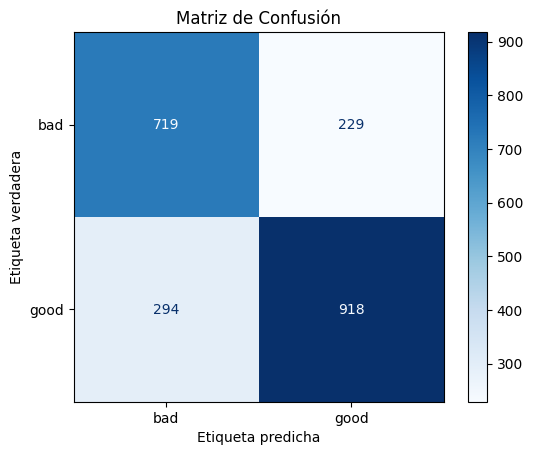

In [49]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=final_rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.xlabel('Etiqueta predicha')
plt.ylabel('Etiqueta verdadera')
plt.title('Matriz de Confusión')
plt.show()

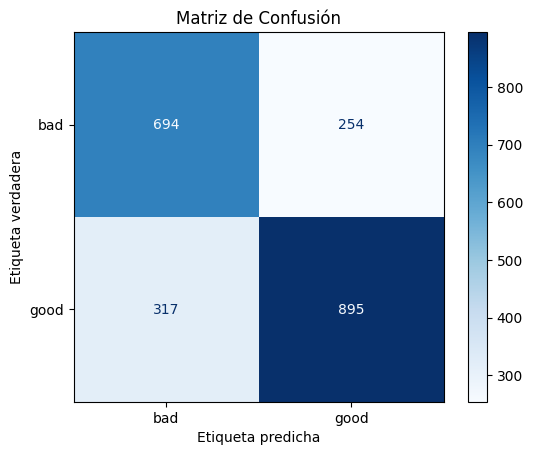

In [68]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=final_rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.xlabel('Etiqueta predicha')
plt.ylabel('Etiqueta verdadera')
plt.title('Matriz de Confusión')
plt.show()

In [12]:
param_grid = {
    'n_estimators':      [100, 200, 300],
    'learning_rate':     [0.01, 0.05, 0.1],
    'num_leaves':        [31, 63, 127],
    'max_depth':         [7, 10, 15],
    'min_child_samples': [10, 20, 30],
    'feature_fraction':  [0.8, 1.0],
    'bagging_fraction':  [0.8, 1.0],
    'bagging_freq':      [0, 5],
}

In [196]:
# lightgbm
df    = pd.read_csv("tabular_data/baseline_data.csv", index_col="oid")
folds = pd.read_csv("folds/stratified_folds.csv",  index_col="oid")

df['mag_p05_alert_inv']       = -df['mag_p05_alert']
df['mag_min_alert_inv']     = -df['mag_min_alert']
df['mag_p25_alert_inv']     = -df['mag_p25_alert']
df['mag_p50_alert_inv']     = -df['mag_p50_alert']

folds = folds.reindex(df.index)

In [197]:
test_fold = np.full(len(df), -1, dtype=int)
for i in range(1, 6):
    mask = folds[f"val_fold{i}"] == 1
    test_fold[mask.values] = i - 1

In [198]:
ps = PredefinedSplit(test_fold=test_fold)

In [199]:
features = [
    "mag_min_alert","mag_max_alert","mag_p05_alert","mag_p25_alert",
    "mag_p50_alert","mag_p75_alert","mag_p95_alert","excess_variance_alert",
    "mag_min_dr","mag_max_dr","mag_p05_dr","mag_p25_dr","mag_p50_dr",
    "mag_p75_dr","mag_p95_dr","excess_variance_dr","distance_delight","hostsize"
]
"""
features = [
    "mag_p95_dr",
    "mag_p75_dr",
    "mag_max_dr",
    "mag_p50_dr",
    "excess_variance_dr",
    "mag_p25_dr",
    "mag_p05_dr",
    "distance_delight",
    "mag_min_dr",
    "mag_p05_alert_inv",
    "mag_min_alert_inv",
    "mag_p25_alert_inv",
    "mag_p50_alert_inv"
]
"""
X = df[features]
y = df["label"].map({"bad": 0, "good": 1})

In [202]:
params = {
    'objective': 'binary',
    'metric':    'accuracy',
    'boosting_type': 'gbdt',
    'is_unbalance':  True,
    'learning_rate': 0.05,
    'num_leaves':    63,
    'max_depth':     10,
    'min_child_samples': 20,
    'verbose':       -1
}

callbacks = [
    lgb.early_stopping(stopping_rounds=10, first_metric_only=True),
    lgb.log_evaluation(period=1)
]

In [ ]:
fold_aucs = []

for fold_idx, (train_idx, val_idx) in enumerate(ps.split(), start=1):
    print(f"\n=== Fold {fold_idx} ===")

    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx],   y.iloc[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dvalid = lgb.Dataset(X_va, label=y_va, reference=dtrain)

    bst = lgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        valid_sets=[dtrain, dvalid],
        valid_names=['train','valid'],
        callbacks=callbacks
    )

    y_prob = bst.predict(X_va, num_iteration=bst.best_iteration)
    auc = roc_auc_score(y_va, y_prob)
    print(f"Fold {fold_idx} AUC: {auc:.4f}")
    fold_aucs.append(auc)

print(f"\nAverage CV AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")


=== Fold 1 ===


TypeError: train() got an unexpected keyword argument 'eval_metric'

In [ ]:
# guardamos el modelo
#joblib.dump(bst, "models/tabular/baseline0_lgbm_new.joblib")

=== Classification Report (Test) ===
              precision    recall  f1-score   support

         bad       0.68      0.75      0.71       948
        good       0.79      0.72      0.75      1212

    accuracy                           0.73      2160
   macro avg       0.73      0.74      0.73      2160
weighted avg       0.74      0.73      0.73      2160



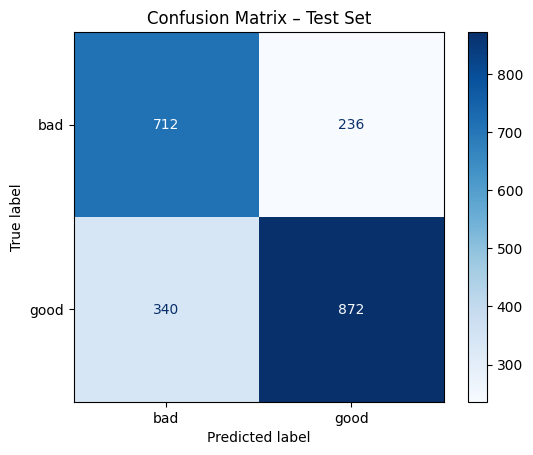

In [ ]:
test_mask = folds["test"] == 1
X_train_full = X.loc[~test_mask]
y_train_full = y.loc[~test_mask]
X_test       = X.loc[test_mask]
y_test       = y.loc[test_mask]

dtrain_full = lgb.Dataset(X_train_full, label=y_train_full)

bst_final = lgb.train(
    params,
    dtrain_full,
    num_boost_round=bst.best_iteration
)

y_prob_test = bst_final.predict(X_test)
y_pred_test = (y_prob_test >= 0.5).astype(int)

print("=== Classification Report (Test) ===")
print(classification_report(y_test, y_pred_test, target_names=["bad","good"], zero_division=0))

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=["bad","good"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix – Test Set")
plt.show()

In [ ]:
df = pd.read_csv("tabular_data/baseline_data.csv", dtype={"label": str})
# Pasamos good a 1 y bad a 0
df["label"] = df["label"].map({"bad": 0, "good": 1})

df['mag_p05_alert_inv']       = -df['mag_p05_alert']
df['mag_min_alert_inv']     = -df['mag_min_alert']
df['mag_p25_alert_inv']     = -df['mag_p25_alert']
df['mag_p50_alert_inv']     = -df['mag_p50_alert']

# 2. Prepara X e y
y = df["label"].values
feature_cols = [c for c in df.columns if c != "label"]

# 3. Itera por cada característica y calcula AUC
results = []
for feat in feature_cols:
    # Selecciona valores no nulos
    vals = df[feat]
    mask = ~vals.isna()
    if mask.sum() < 10:
        # muy pocas muestras, saltar
        continue

    # Para evitar errores si la variable es constante:
    if vals[mask].nunique() < 2:
        continue

    try:
        auc = roc_auc_score(y[mask], vals[mask])
    except ValueError:
        # Si y o vals tienen problemas
        continue

    results.append({
        "feature":    feat,
        "auc":        auc,
        "invertible": auc < 0.5,
        "auc_adj":    auc if auc >= 0.5 else 1 - auc
    })

# 4. Organiza en DataFrame y ordénalo
df_auc = pd.DataFrame(results)
df_auc = df_auc.sort_values("auc_adj", ascending=False).reset_index(drop=True)


In [ ]:
df_auc

,feature,auc,invertible,auc_adj
0,mag_p95_dr,0.700398,False,0.700398
1,mag_p75_dr,0.697895,False,0.697895
2,n_points_dr,0.302196,True,0.697804
3,mag_max_dr,0.694721,False,0.694721
4,mag_p50_dr,0.694284,False,0.694284
5,excess_variance_dr,0.692793,False,0.692793
6,mag_p25_dr,0.684463,False,0.684463
7,mag_p05_dr,0.655455,False,0.655455
8,distance_delight,0.647043,False,0.647043
9,mag_min_dr,0.645090,False,0.645090
